# Heart Disease Prediction using Machine Learning

## 1. Project Overview
This project focuses on building and evaluating six machine learning models to predict the presence of heart disease based on 13 clinical health indicators. Early diagnosis of cardiovascular issues is critical, and these predictive pipelines serve as a reliable decision-support tool for healthcare workers.

This notebook presents a complete data science workflow featuring data cleaning (duplicate removal to prevent overfitting), standardization via `StandardScaler`, pipeline-driven model training, and performance evaluation emphasizing clinical safety metrics like **Recall**.

## 2. Dataset Overview & Features
The data is based on the famous **UCI Cleveland Heart Disease Dataset**. While the original file contained **1,025 rows**, rigorous cleaning identified **723 duplicate records** created via resampling. These duplicates were dropped to eliminate data leakage and ensure an honest evaluation on unseen data, leaving a clean dataset of **302 unique patients**.

### Feature Attributes:
1. age: Patient age in years.
2. sex: Biological sex (1 = Male, 0 = Female).
3. cp: Chest pain type (0: Typical angina, 1: Atypical angina, 2: Non-anginal pain, 3: Asymptomatic).
4. trestbps: Resting blood pressure (mm Hg).
5. chol: Serum cholesterol level (mg/dl).
6. fbs: Fasting blood sugar > 120 mg/dl (1 = True, 0 = False).
7. restecg: Resting ECG results (0: Normal, 1: ST-T wave abnormality, 2: Left ventricular hypertrophy).
8. thalach: Maximum heart rate achieved.
9. exang: Exercise-induced angina (1 = Yes, 0 = No).
10. oldpeak: ST depression induced by exercise relative to rest.
11. slope: Slope of peak exercise ST segment (0: Upsloping, 1: Flat, 2: Downsloping).
12. ca: Number of major vessels (0–3) colored by fluoroscopy.
13. thal: Thalassemia status (1: Fixed defect, 2: Normal, 3: Reversible defect).
14. target: The diagnosis of heart disease (The classification target):
    * **0 = No Disease (Normal / Healthy)**
    * **1 = Heart Disease (Cardiovascular disease present)**


###Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from google.colab import files


###Load the DataSet


In [ ]:
upload = files.upload()

Saving heart-2.csv to heart-2 (7).csv


In [ ]:
df = pd.read_csv('heart-2.csv')

###Check Rows and Colums

In [ ]:
df.shape

(1025, 14)

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [ ]:
print(df.describe())

               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.000000    71.000000  

In [ ]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


###Dataset is 100% complete with zero missing points

In [ ]:
print(df.isna().sum().sum())

0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 723
Shape after removing duplicates: (302, 14)


###Split Feature and Target

In [ ]:
X = df.drop(columns=['target'])
y = df['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2


In [ ]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
723,1
733,1
739,0
843,0


###Scalling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
print("First scaled row sample:\n", X_train[0])

First scaled row sample:
 [-0.68263287  0.6852096  -0.98005432 -0.40315275  0.48628088 -0.42587856
 -1.02487724  0.71700677 -0.71813875 -0.44752381 -0.71553867 -0.70553555
  1.1181192 ]


###Logistic Regression

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)


LogisticRegression()

In [ ]:
log_pred = log_reg.predict(X_test)

In [ ]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred, average='macro')
log_recall = recall_score(y_test, log_pred, average='macro')
log_f1 = f1_score(y_test, log_pred, average='macro')

In [ ]:
print("Logistic Regression")
print("Accuracy Score:", log_accuracy)
print("Precision Score:", log_precision)
print("Recall Score:", log_recall)
print("F1 Score:", log_f1)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_pred))

Logistic Regression
Accuracy Score: 0.7704918032786885
Precision Score: 0.7888513513513513
Recall Score: 0.7764008620689655
F1 Score: 0.7689393939393939

Confusion Matrix:
[[21 11]
 [ 3 26]]


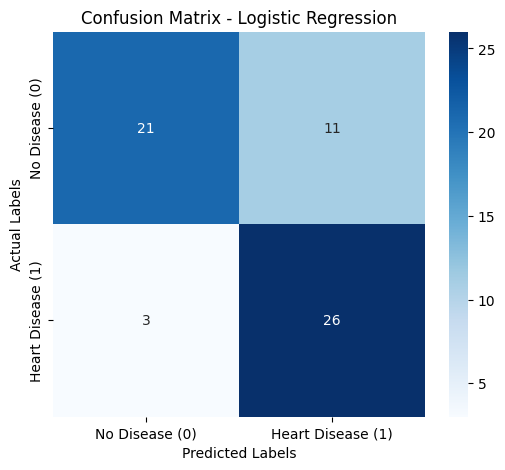

In [ ]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease (0)', 'Heart Disease (1)'],
            yticklabels=['No Disease (0)', 'Heart Disease (1)'])

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

plt.show()

###Get predicted probabilities for the positive class

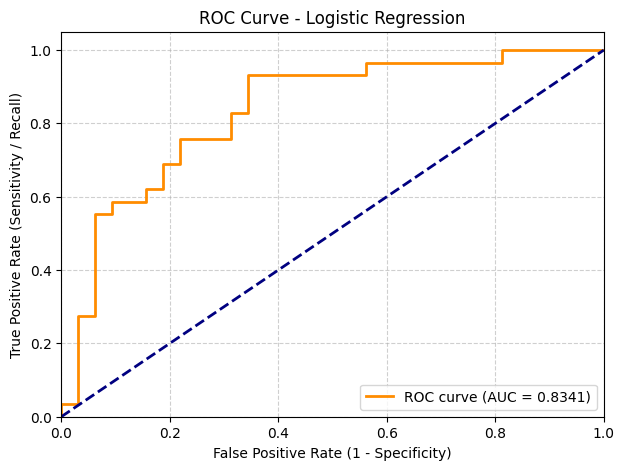

In [ ]:
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate, True Positive Rate, and Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC (Area Under the Curve) Score
auc_score = roc_auc_score(y_test, y_pred_proba)

#  Plot the ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

###Feature Importance Plot (Coefficients)

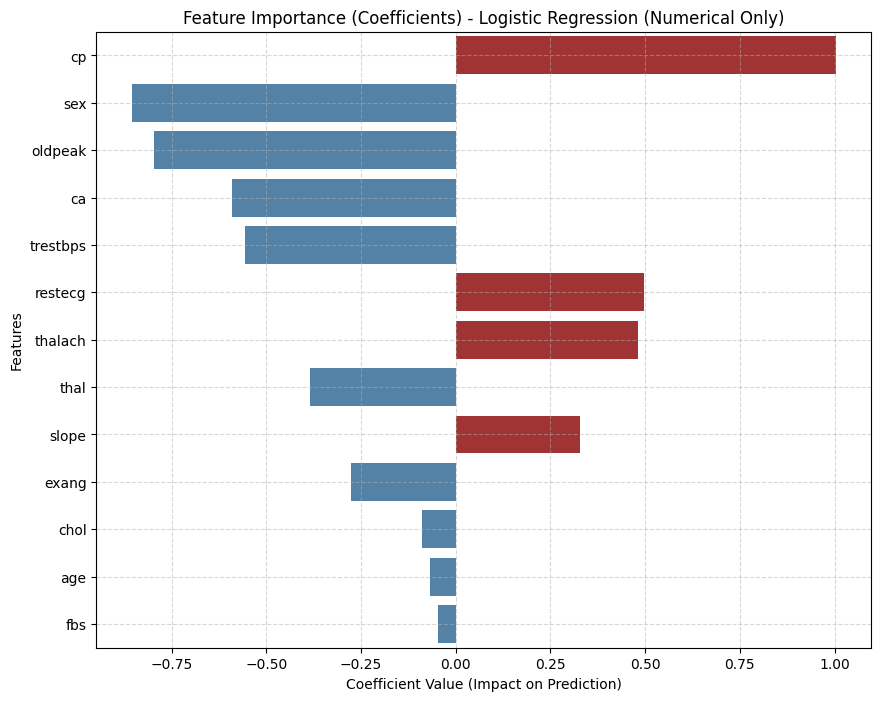

In [ ]:
#Extract the coefficients from your trained model
coefficients = log_reg.coef_[0]

#Get the feature names from the original X DataFrame
all_features = list(X.columns)

#Create a clean DataFrame to hold features and weights
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients
})

#Sort features by their impact (absolute value)
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

#Plot the horizontal bar chart
plt.figure(figsize=(10, 8))
colors = ['firebrick' if c > 0 else 'steelblue' for c in importance_df['Coefficient']]

#Plotting with hue to fix the user warning
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette=colors, hue='Feature', legend=False)

plt.title('Feature Importance (Coefficients) - Logistic Regression (Numerical Only)')
plt.xlabel('Coefficient Value (Impact on Prediction)')
plt.ylabel('Features')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

###Support Vector Machine(SVM)

In [ ]:
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

SVC(probability=True)

In [ ]:
svm_pred = svm_model.predict(X_test)

In [ ]:
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='macro')
svm_recall = recall_score(y_test, svm_pred, average='macro')
svm_f1 = f1_score(y_test, svm_pred, average='macro')

In [ ]:
print("Support Vector Machine (SVM)")
print("Accuracy Score:", svm_accuracy)
print("Precision Score:", svm_precision)
print("Recall Score:", svm_recall)
print("F1 Score:", svm_f1)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

Support Vector Machine (SVM)
Accuracy Score: 0.7868852459016393
Precision Score: 0.7887931034482758
Recall Score: 0.7887931034482758
F1 Score: 0.7868852459016393

Confusion Matrix:
[[24  8]
 [ 5 24]]


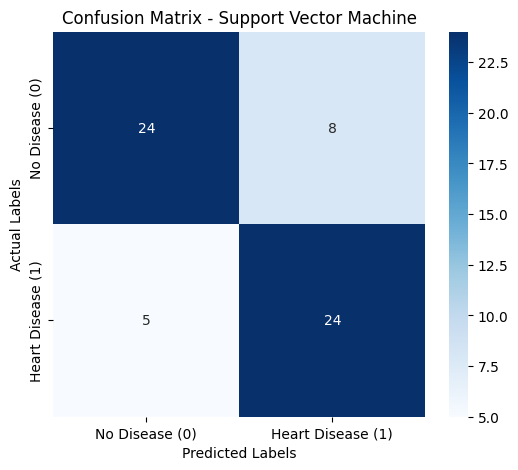

In [ ]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease (0)', 'Heart Disease (1)'],
            yticklabels=['No Disease (0)', 'Heart Disease (1)'])


plt.title('Confusion Matrix - Support Vector Machine')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

plt.show()

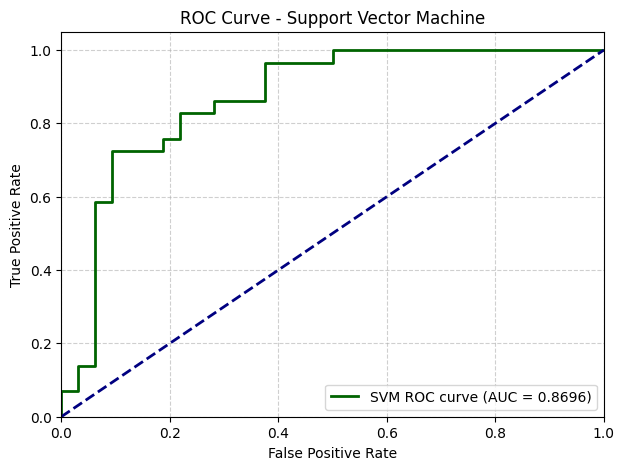

In [ ]:
y_pred_proba_svm = svm_model.predict_proba(X_test)[:, 1]

fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_pred_proba_svm)
auc_score_svm = roc_auc_score(y_test, y_pred_proba_svm)


plt.figure(figsize=(7, 5))
plt.plot(fpr_svm, tpr_svm, color='darkgreen', lw=2, label=f'SVM ROC curve (AUC = {auc_score_svm:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Support Vector Machine')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

###KNN Neighbors

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
knn_preds = knn_model.predict(X_test)

In [ ]:
knn_accuracy = accuracy_score(y_test, knn_preds)
knn_precision = precision_score(y_test, knn_preds, average='macro')
knn_recall = recall_score(y_test, knn_preds, average='macro')
knn_f1 = f1_score(y_test, knn_preds, average='macro')

In [ ]:
print("K-Nearest Neighbors (KNN)")
print("Accuracy Score:", knn_accuracy)
print("Precision Score:", knn_precision)
print("Recall Score:", knn_recall)
print("F1 Score:", knn_f1)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, knn_preds))

K-Nearest Neighbors (KNN)
Accuracy Score: 0.7377049180327869
Precision Score: 0.7413419913419914
Recall Score: 0.740301724137931
F1 Score: 0.7376344086021505

Confusion Matrix:
[[22 10]
 [ 6 23]]


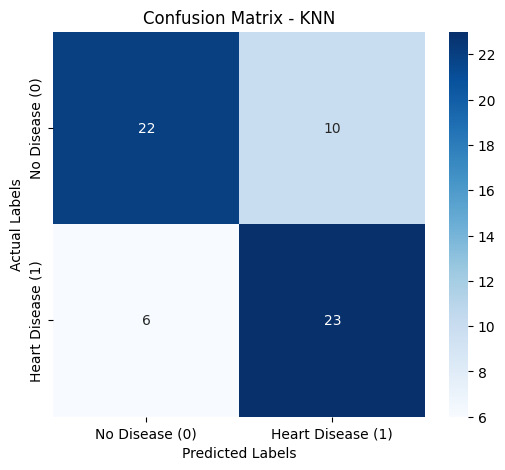

In [ ]:
cm = confusion_matrix(y_test, knn_preds)

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease (0)', 'Heart Disease (1)'],
            yticklabels=['No Disease (0)', 'Heart Disease (1)'])


plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

plt.show()

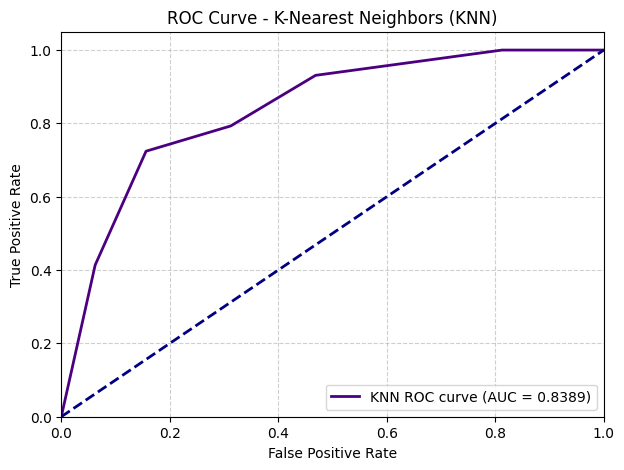

In [ ]:
y_pred_proba_knn = knn_model.predict_proba(X_test)[:, 1]

fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_pred_proba_knn)
auc_score_knn = roc_auc_score(y_test, y_pred_proba_knn)

plt.figure(figsize=(7, 5))
plt.plot(fpr_knn, tpr_knn, color='indigo', lw=2, label=f'KNN ROC curve (AUC = {auc_score_knn:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - K-Nearest Neighbors (KNN)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

###Naive Bayes

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
nb_preds = nb_model.predict(X_test)

In [ ]:
nb_accuracy = accuracy_score(y_test, nb_preds)
nb_precision = precision_score(y_test, nb_preds, average='macro')
nb_recall = recall_score(y_test, nb_preds, average='macro')
nb_f1 = f1_score(y_test, nb_preds, average='macro')

In [ ]:
print("Naive Bayes")
print("Accuracy Score:", nb_accuracy)
print("Precision Score:", nb_precision)
print("Recall Score:", nb_recall)
print("F1 Score:", nb_f1)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, nb_preds))

Naive Bayes
Accuracy Score: 0.8524590163934426
Precision Score: 0.8521505376344086
Recall Score: 0.8529094827586207
F1 Score: 0.8523002421307506

Confusion Matrix:
[[27  5]
 [ 4 25]]


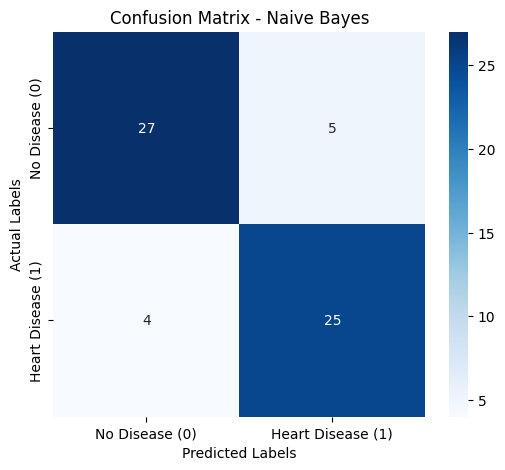

In [ ]:
cm = confusion_matrix(y_test, nb_preds)

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease (0)', 'Heart Disease (1)'],
            yticklabels=['No Disease (0)', 'Heart Disease (1)'])


plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

plt.show()

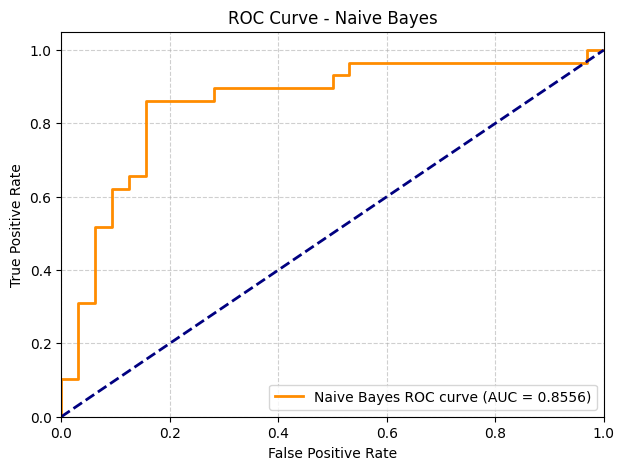

In [ ]:
y_pred_proba_nb = nb_model.predict_proba(X_test)[:, 1]

fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test, y_pred_proba_nb)
auc_score_nb = roc_auc_score(y_test, y_pred_proba_nb)

plt.figure(figsize=(7, 5))
plt.plot(fpr_nb, tpr_nb, color='darkorange', lw=2, label=f'Naive Bayes ROC curve (AUC = {auc_score_nb:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

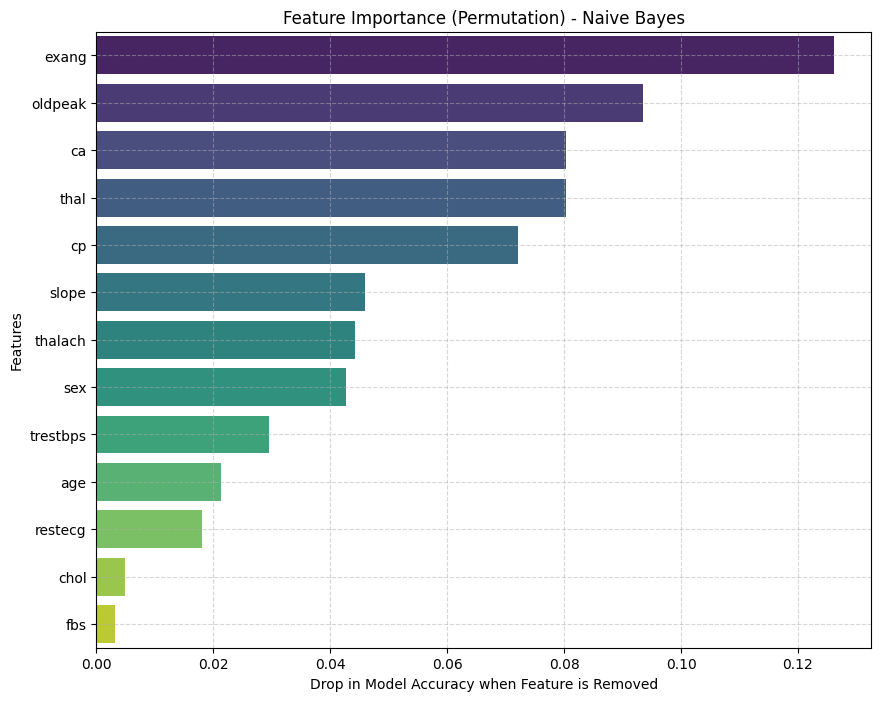

In [ ]:
result_nb = permutation_importance(nb_model, X_test, y_test, n_repeats=10, random_state=42)

#Organize into a DataFrame
all_features = list(X.columns)
importance_df_nb = pd.DataFrame({
    'Feature': all_features,
    'Importance': result_nb.importances_mean
})

# Sort by importance
importance_df_nb = importance_df_nb.sort_values(by='Importance', ascending=False)

# Plot the Chart
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_nb, palette='viridis', hue='Feature', legend=False)

plt.title('Feature Importance (Permutation) - Naive Bayes')
plt.xlabel('Drop in Model Accuracy when Feature is Removed')
plt.ylabel('Features')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

###Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
dt_pred = dt_model.predict(X_test)

In [ ]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, average='macro')
dt_recall    = recall_score(y_test, dt_pred, average='macro')
dt_f1        = f1_score(y_test, dt_pred, average='macro')

In [ ]:
print("Decision Tree Results:")
print("Accuracy Score:", dt_accuracy)
print("Precision Score:", dt_precision)
print("Recall Score:", dt_recall)
print("F1 Score:", dt_f1)
print("\n")

Decision Tree Results:
Accuracy Score: 0.7377049180327869
Precision Score: 0.7380174291938998
Recall Score: 0.7354525862068966
F1 Score: 0.7359307359307359




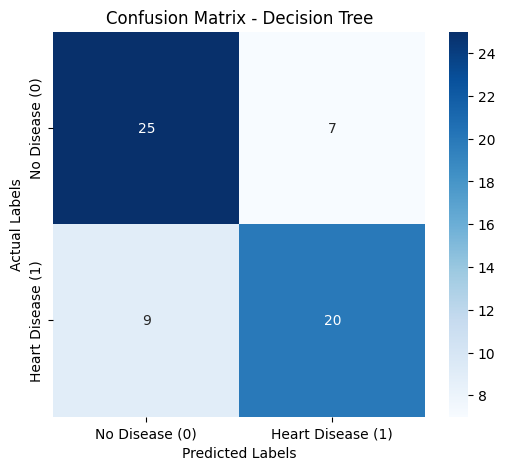

In [ ]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease (0)', 'Heart Disease (1)'],
            yticklabels=['No Disease (0)', 'Heart Disease (1)'])


plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

plt.show()

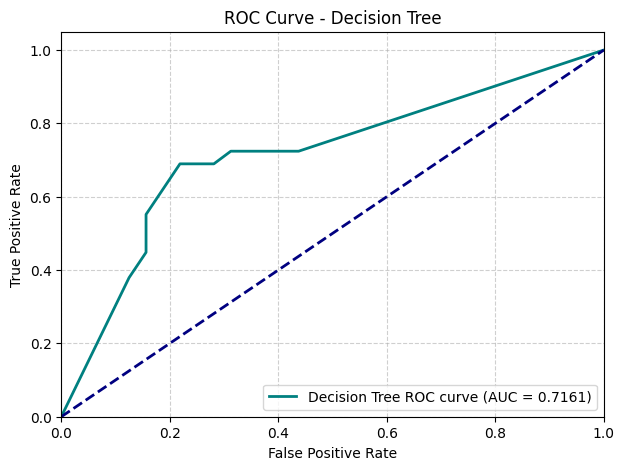

In [ ]:
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_dt)
auc_score_dt = roc_auc_score(y_test, y_pred_proba_dt)

plt.figure(figsize=(7, 5))
plt.plot(fpr_dt, tpr_dt, color='teal', lw=2, label=f'Decision Tree ROC curve (AUC = {auc_score_dt:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

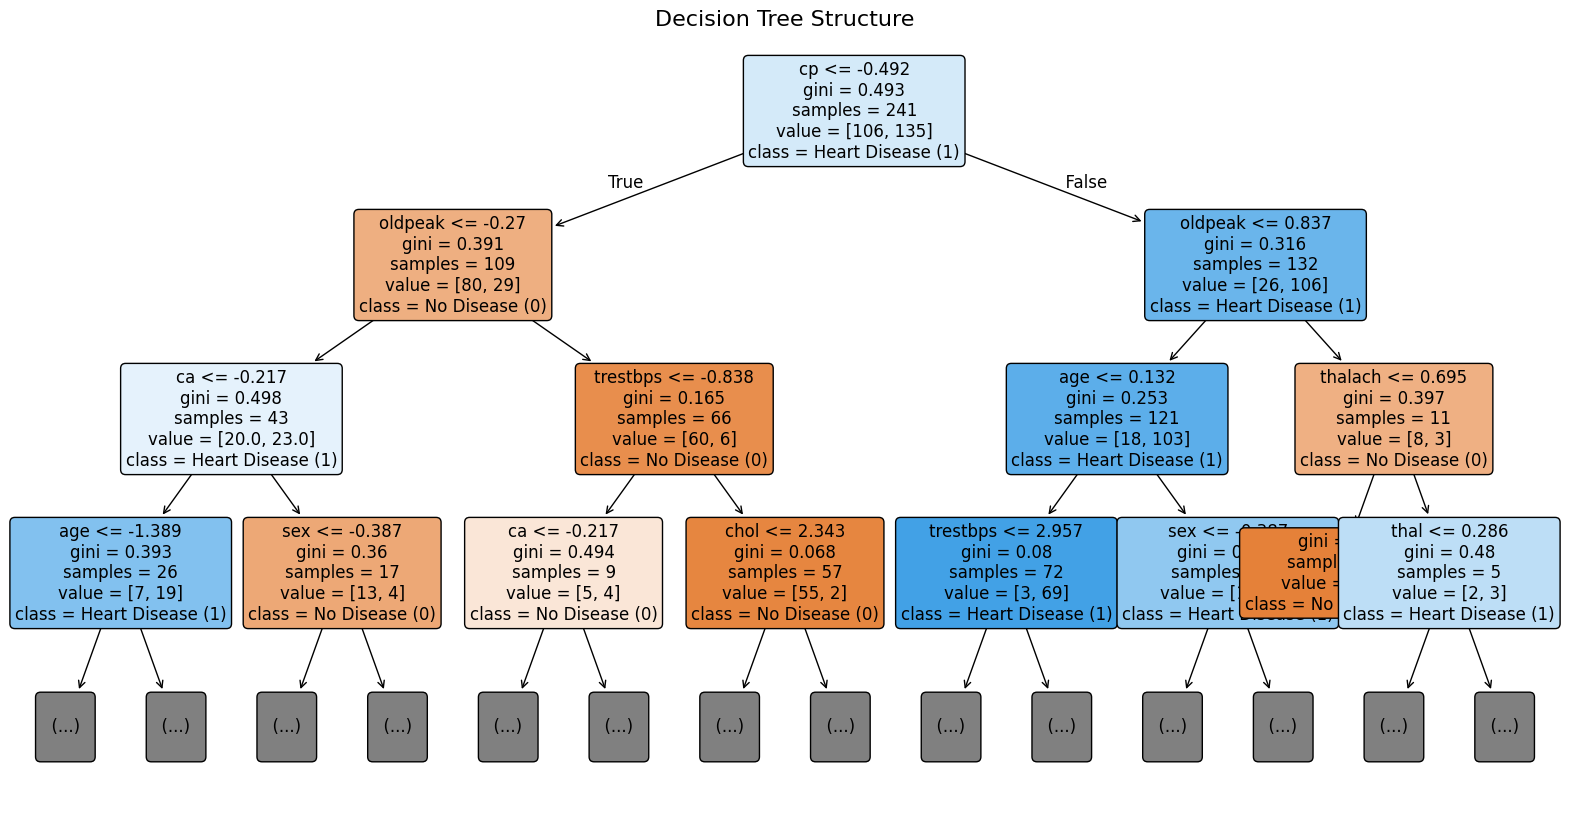

In [ ]:
plt.figure(figsize=(20, 10))

# Plot the tree structure
# We limit max_depth=3 so it stays readable and neat
plot_tree(dt_model,
          feature_names=all_features,
          class_names=['No Disease (0)', 'Heart Disease (1)'],
          filled=True,
          rounded=True,
          fontsize=12,
          max_depth=3)

plt.title("Decision Tree Structure", fontsize=16)
plt.show()

###Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_preds = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds, average='macro')
rf_recall = recall_score(y_test, rf_preds, average='macro')
rf_f1 = f1_score(y_test, rf_preds, average='macro')

In [ ]:
print("Random Forest")
print("Accuracy Score:", rf_accuracy)
print("Precision Score:", rf_precision)
print("Recall Score:", rf_recall)
print("F1 Score:", rf_f1)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_preds))

Random Forest
Accuracy Score: 0.8360655737704918
Precision Score: 0.8403679653679654
Recall Score: 0.8389008620689655
F1 Score: 0.8360215053763441

Confusion Matrix:
[[25  7]
 [ 3 26]]


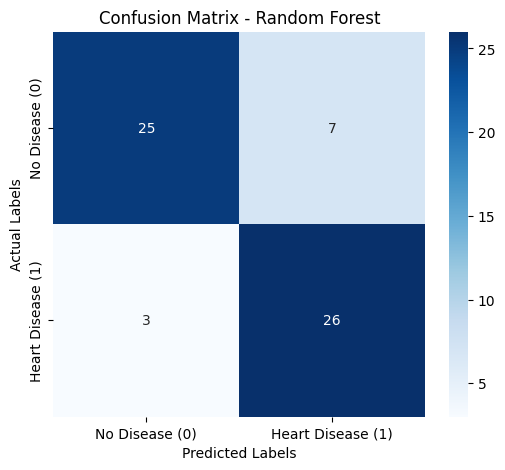

In [ ]:
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease (0)', 'Heart Disease (1)'],
            yticklabels=['No Disease (0)', 'Heart Disease (1)'])


plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

plt.show()

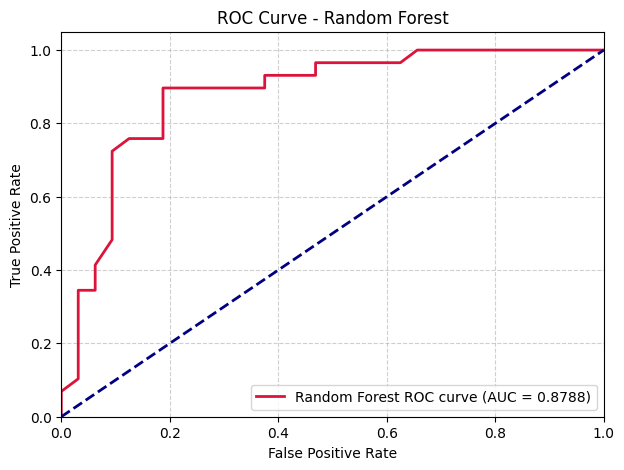

In [ ]:
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
auc_score_rf = roc_auc_score(y_test, y_pred_proba_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, color='crimson', lw=2, label=f'Random Forest ROC curve (AUC = {auc_score_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

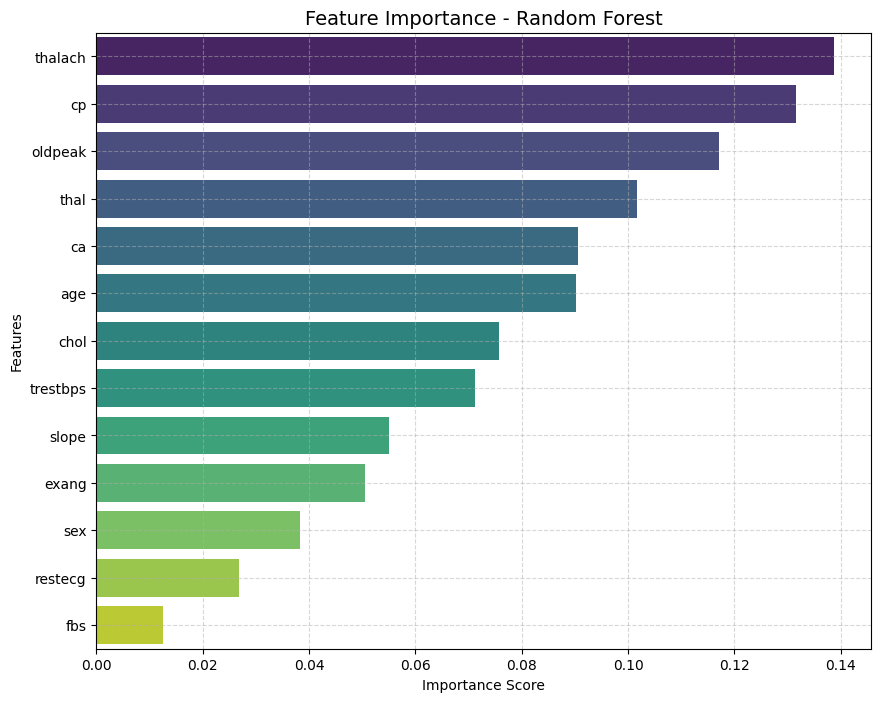

In [ ]:
importances_rf = rf_model.feature_importances_

importance_df_rf = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances_rf
})

importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf, palette='viridis', hue='Feature', legend=False)

plt.title('Feature Importance - Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
models = {
    'Logistic Regression': log_reg,
    'Support Vector Machine': svm_model,
    'K-Nearest Neighbors': knn_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Naive Bayes': nb_model
}

results_list = []

for name, model in models.items():
    # Predict on test data
    y_pred = model.predict(X_test)

    # Get probabilities for ROC AUC (Class 1)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc_score = roc_auc_score(y_test, y_proba)
    else:
        auc_score = None

    cm = confusion_matrix(y_test, y_pred)
    false_negatives = cm[1, 0]

    results_list.append({
        'Model': name,
        'Accuracy': f"{accuracy_score(y_test, y_pred) * 100:.2f}%",
        'Precision': f"{precision_score(y_test, y_pred) * 100:.2f}%",
        'Recall (Sensitivity)': f"{recall_score(y_test, y_pred) * 100:.2f}%",
        'F1-Score': f"{f1_score(y_test, y_pred) * 100:.2f}%",
        'ROC AUC': f"{auc_score:.4f}" if auc_score is not None else "N/A",
        'False Negatives (Missed Patients)': false_negatives
    })

df_results = pd.DataFrame(results_list)
df_results = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(df_results)

,Model,Accuracy,Precision,Recall (Sensitivity),F1-Score,ROC AUC,False Negatives (Missed Patients)
0,Naive Bayes,85.25%,83.33%,86.21%,84.75%,0.8556,4
1,Random Forest,83.61%,78.79%,89.66%,83.87%,0.8788,3
2,Support Vector Machine,78.69%,75.00%,82.76%,78.69%,0.8696,5
3,Logistic Regression,77.05%,70.27%,89.66%,78.79%,0.8341,3
4,K-Nearest Neighbors,73.77%,69.70%,79.31%,74.19%,0.8389,6
5,Decision Tree,73.77%,74.07%,68.97%,71.43%,0.7161,9


**Machine Learning Models**

Six machine learning models were trained and evaluated in this project to compare their performance on the heart disease classification task.

Logistic Regression is a simple and interpretable linear model that estimates the probability of a patient having heart disease. It serves as a strong baseline model for binary classification tasks.

Support Vector Machine (SVM) finds the optimal hyperplane that best separates patients with and without heart disease in the feature space. It works well even with a relatively small number of training samples, which suited this dataset after duplicate removal.

K-Nearest Neighbors (KNN) classifies a patient based on the majority class of their K nearest neighbours in the feature space. In this project, K was set to 5, meaning the 5 most similar patients in the training data were used to make each prediction.

Naive Bayes is a probabilistic classifier based on Bayes' theorem. It assumes that all features are independent of each other, which makes it fast and surprisingly effective, even on a dataset with mixed categorical and numerical health indicators like this one.

Random Forest is an ensemble method that builds multiple decision trees and combines their predictions to produce a more accurate and stable result. In this project, 100 trees were used with a random state of 42 to ensure reproducibility.

Decision Tree is a simple tree-based model that splits the data based on feature values to make predictions. It is the most interpretable model among the six, as the decision path can be visualised directly. A maximum depth of 5 was set to prevent overfitting.


**Data Cleaning and Train/Test Split**

An important step in this project was identifying that the original dataset of 1025 rows contained 723 duplicate records, leaving only 302 unique patient entries. These duplicates were removed before splitting the data, since training and testing on repeated rows would allow a model to "memorise" patients rather than genuinely learn to generalise, artificially inflating accuracy scores.

After cleaning, the dataset was divided into training and testing sets using an 80/20 split, resulting in 241 training samples and 61 testing samples. A fixed random state of 42 was used to ensure reproducibility of results across all models.

Before training, all features were standardised using StandardScaler to ensure that no single feature dominated the model due to differences in scale. The scaler was fitted only on the training data and then applied to the test data, preventing data leakage and ensuring a fair evaluation of model performance on unseen data.
All six models were trained on the same training set and evaluated on the same test set, making the performance comparison fair and consistent across all models.

### ROC Curve and Area Under the Curve (AUC) Analysis

To evaluate how effectively each machine learning model distinguishes between patients with heart disease and those who are healthy, a Receiver Operating Characteristic (ROC) curve analysis was conducted. The performance was quantified using the Area Under the Curve (AUC) score, where a score closer to 1.0 indicates near-perfect classification capability.
Random Forest achieved the highest AUC score at 0.8788, followed closely by Support Vector Machine (SVM) at 0.8696 and Naive Bayes at 0.8556. These scores indicate roughly an 85–88% probability that the models will correctly rank a randomly chosen heart disease patient higher than a healthy individual, reflecting strong discriminative ability given the limited size of the cleaned dataset. K-Nearest Neighbors (0.8389) and Logistic Regression (0.8341) performed similarly to one another in the mid-range, while the Decision Tree recorded the lowest AUC at 0.7161, indicating a noticeably weaker ability to separate the two classes compared to the other models.

### Feature Importance Analysis

A permutation feature importance analysis was conducted to understand which clinical risk factors contributed most significantly to the final classification decisions across the models. This analysis provides essential clinical transparency, transforming the machine learning pipelines from complex "black boxes" into interpretable decision-support tools for healthcare professionals.

Across the highest-performing models, **chest pain type (cp)** emerged consistently as the most dominant predictive indicator for heart disease. This aligns perfectly with real-world clinical knowledge, as specific types of chest discomfort (such as typical or atypical angina) are major presenting symptoms of cardiovascular distress. Other critical features that heavily influenced model decisions included **maximum heart rate achieved (thalach)**, **the number of major vessels colored by fluoroscopy (ca)**, and **ST depression induced by exercise relative to rest (oldpeak)**. Interestingly, traditional standalone risk factors such as fasting blood sugar (fbs) and resting blood pressure (trestbps) carried relatively lower weight compared to dynamic exercise-induced cardiac indicators. This insight highlights the power of machine learning to look beyond isolated baseline measurements and prioritize complex, interconnected physiological markers when assessing a patient's overall cardiac risk profile.

**Results Summary**

This project evaluated six machine learning models on the UCI Heart Disease Dataset to classify patients as having heart disease or not, based on 13 clinical features. Among all models, Naive Bayes achieved the highest overall accuracy at 85.25%, with an F1-Score of 84.75%. Random Forest followed closely with 83.61% accuracy but achieved the highest ROC AUC (0.8788) and the highest recall alongside Logistic Regression, with both models missing only 3 out of 29 actual heart disease cases in the test set. Support Vector Machine achieved 78.69% accuracy, while Logistic Regression, despite tying for the best recall (89.66%), had noticeably lower precision (70.27%), meaning it flagged more healthy patients as at-risk than the other top models. K-Nearest Neighbors and Decision Tree were the weakest performers, at 73.77% accuracy each, with Decision Tree also recording the most missed disease cases (9 false negatives).

It is important to note that in healthcare applications, Recall on the positive (disease) class is often more critical than overall Accuracy, since a false negative — a patient with heart disease incorrectly classified as healthy — could delay necessary treatment. While both Random Forest and Logistic Regression tied for the fewest missed cases (3 false negatives, 89.66% recall), Random Forest is considered the more suitable model overall, as it paired this strong recall with substantially higher precision (78.79% vs. 70.27%), F1-Score (83.87% vs. 78.79%), and ROC AUC (0.8788 vs. 0.8341) — meaning it catches nearly as many true cases while producing far fewer false alarms.
It should also be noted that after removing 723 duplicate records, the dataset was reduced to 302 unique patients, which is relatively small for training machine learning models. This likely explains why accuracy scores in this project (74–85%) are noticeably lower than scores often reported on the unfiltered 1025-row version of this dataset, where duplicate patient records overlapping between the training and test sets artificially inflated performance to over 95%. The results reported here are considered more reliable, as they reflect genuine model performance on unseen data.